# EDA: Predictive Maintenance Failure-Risk Dataset

Exploratory analysis of the AI4I 2020 dataset (Matzka, 2020). All plotting and feature-engineering logic lives in `src/` and is imported here rather than duplicated -- this notebook is for exploration and narration, not core logic.

Full citation and dataset description: see `../README.md`.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
from src.data import load_raw_data, load_processed_data
from src.eda import (
    plot_class_balance,
    plot_correlation_matrix,
    plot_failure_type_breakdown,
    plot_feature_distributions,
    plot_type_vs_failure,
)

pd.set_option('display.max_columns', None)

## Load data and take a first look

In [2]:
raw = load_raw_data()
print(raw.shape)
raw.head()

(10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [3]:
raw.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [4]:
raw.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

## Class balance

The dataset is heavily imbalanced: only ~3.4% of rows are labelled a machine failure. This drives every modeling and evaluation decision downstream (stratified split, class-weighting/SMOTE, reporting precision/recall/PR-AUC instead of accuracy).

In [5]:
df = load_processed_data()
df['Target'].value_counts(normalize=True) * 100

Target
0    96.61
1     3.39
Name: proportion, dtype: float64

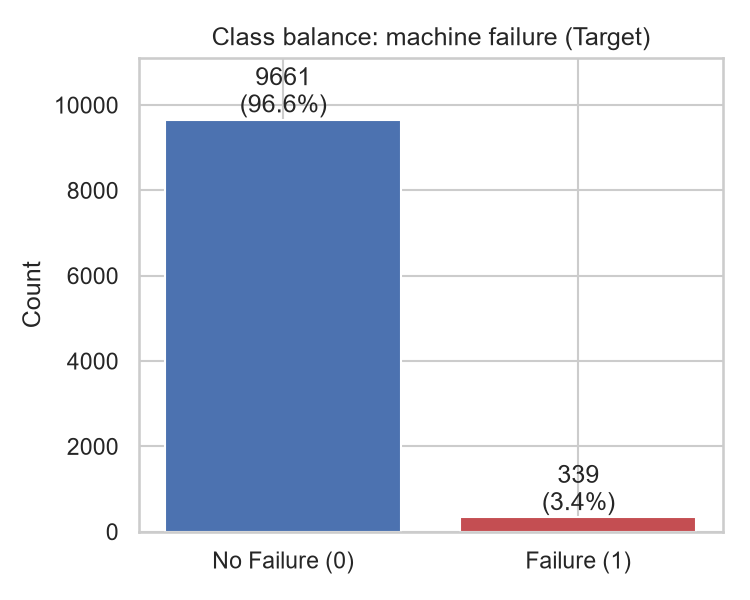

In [6]:
plot_class_balance(df)
from IPython.display import Image
Image('../figures/class_balance.png')

## Failure type breakdown

`Failure Type` gives the specific failure mode for rows where `Target == 1`. Some modes have very few examples -- this matters for how reliably a model can learn to recognise them (see `MODEL_CARD.md` for the quantified breakdown).

In [7]:
df[df['Target'] == 1]['Failure Type'].value_counts()

Failure Type
Heat Dissipation Failure    112
Power Failure                95
Overstrain Failure           78
Tool Wear Failure            45
No Failure                    9
Name: count, dtype: int64

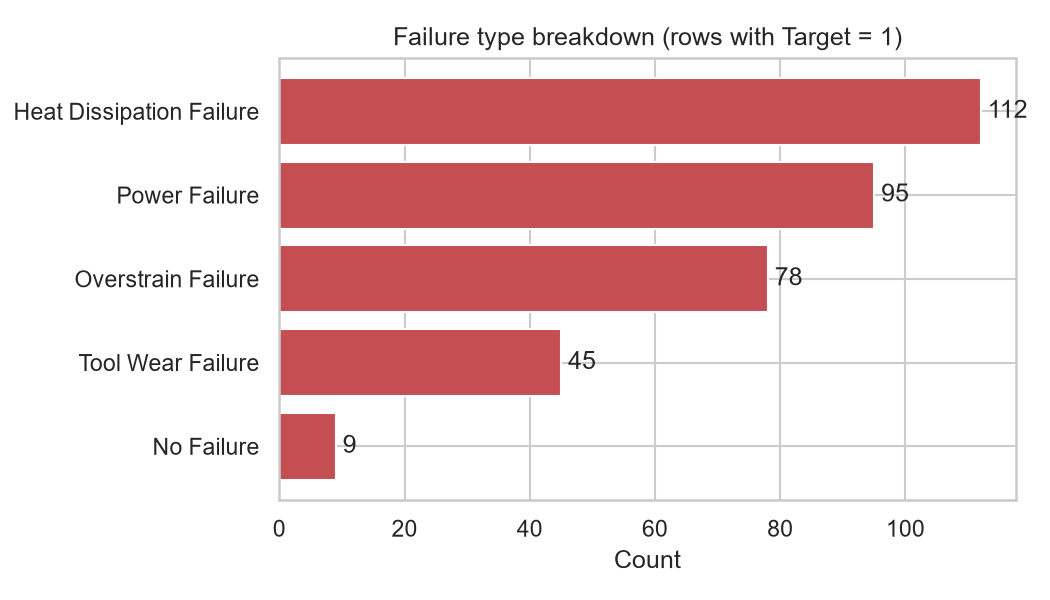

In [8]:
plot_failure_type_breakdown(df)
Image('../figures/failure_type_breakdown.png')

## Known label inconsistencies

The published AI4I 2020 dataset has two documented quirks between `Target` and `Failure Type` (see `src/data.py` docstrings and `BUILD_LOG.md`): 18 rows tagged `Random Failures` with `Target == 0`, and 9 rows with `Target == 1` but `Failure Type == 'No Failure'`. These are kept (not real failures to hide) but flagged.

In [9]:
df['Label inconsistent'].sum(), df['Label inconsistent'].mean() * 100

(np.int64(27), np.float64(0.27))

## Feature distributions by failure status

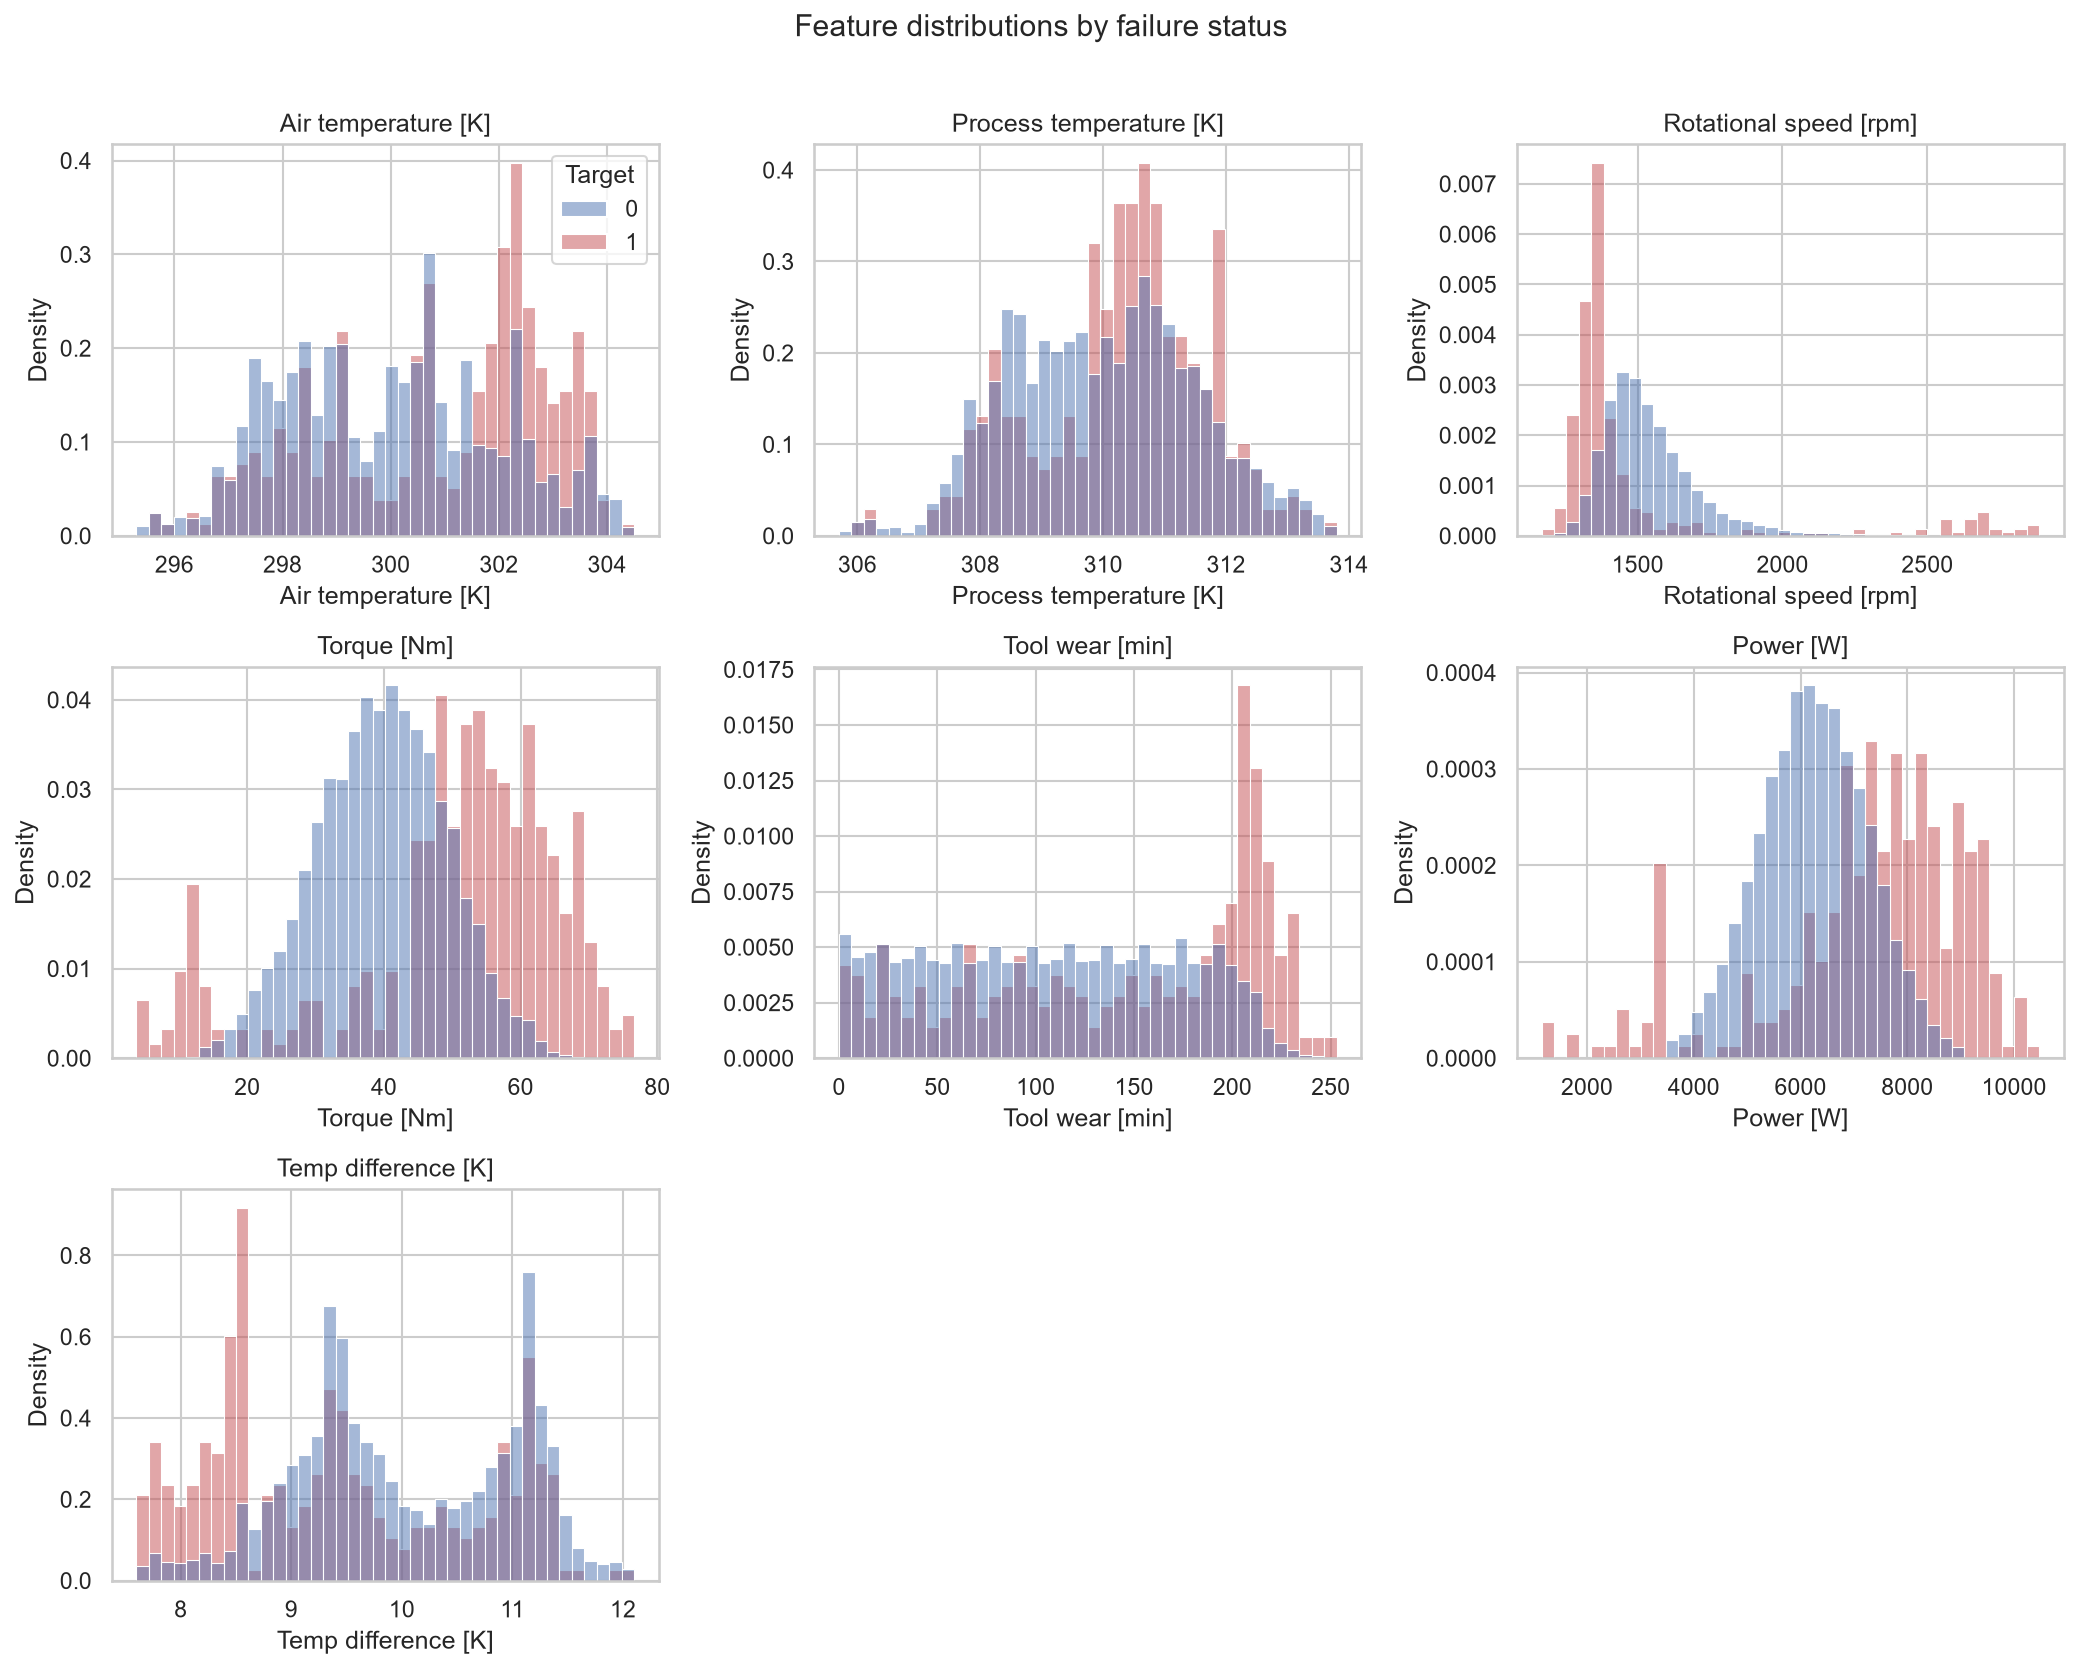

In [10]:
plot_feature_distributions(df)
Image('../figures/feature_distributions.png')

## Correlation matrix

Includes the two engineered features: `Power [W]` (torque x angular velocity) and `Temp difference [K]` (process - air temperature), both physically motivated by the dataset's own failure-mode definitions (Power Failure, Heat Dissipation Failure).

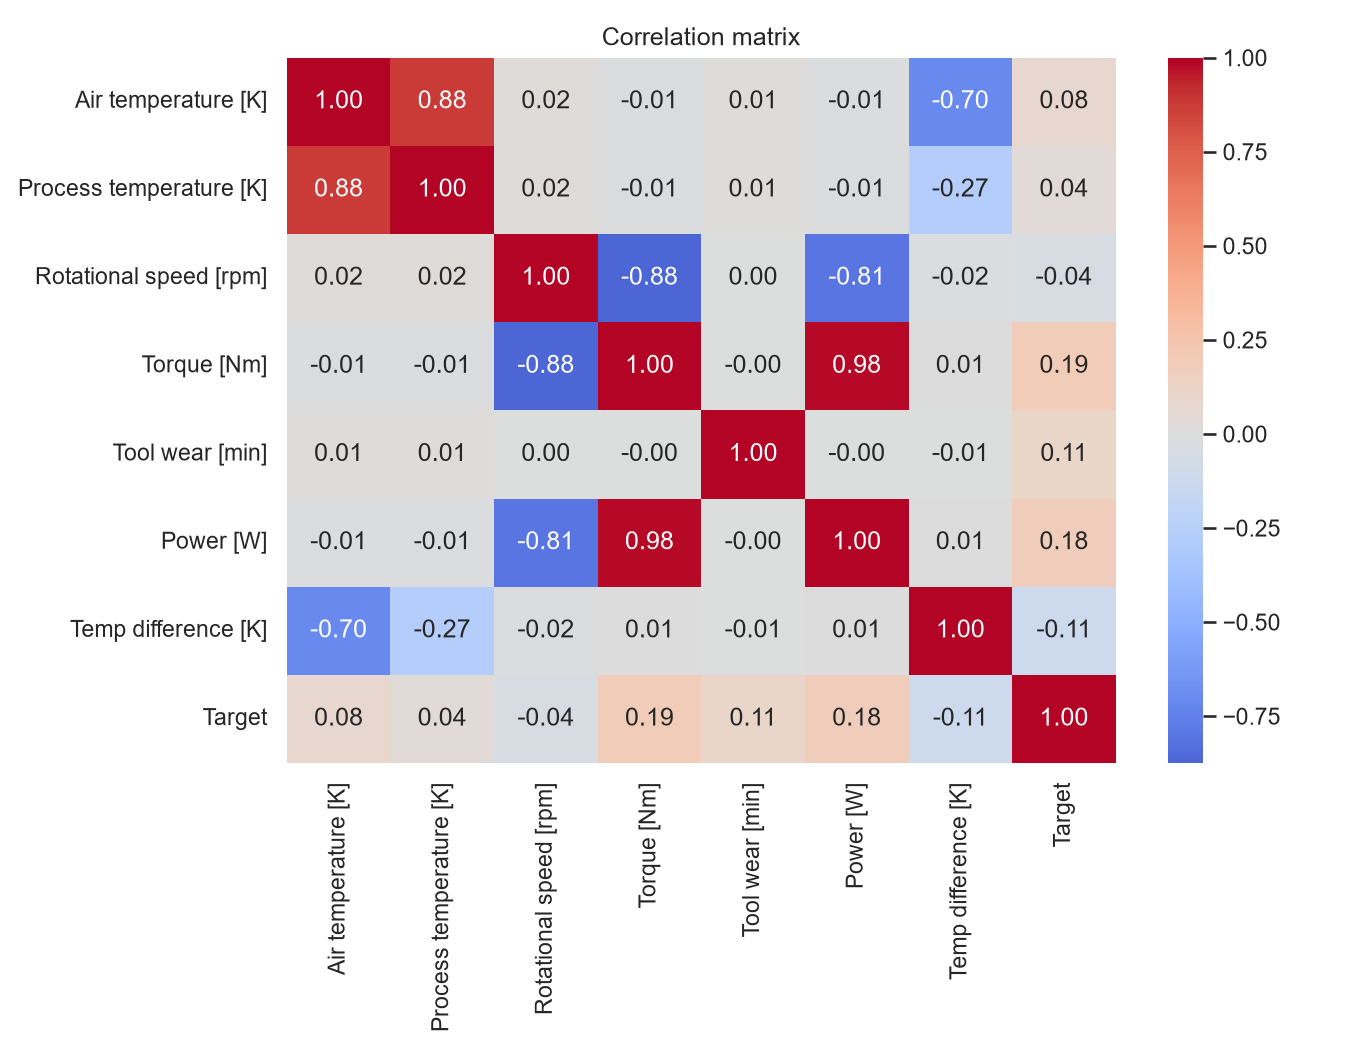

In [11]:
plot_correlation_matrix(df)
Image('../figures/correlation_matrix.png')

## Failure rate by product quality type (L/M/H)

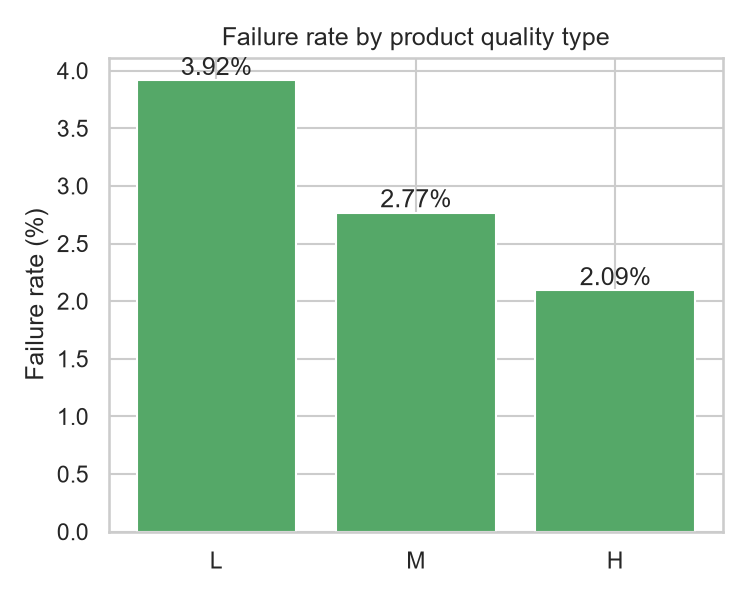

In [12]:
plot_type_vs_failure(df)
Image('../figures/failure_rate_by_type.png')

## Takeaways

- Severe class imbalance (3.4% positive) -> stratified split, class-weighting/SMOTE, and PR-AUC as the primary ranking metric (see `src/train.py`, `src/evaluate.py`).
- Torque and rotational speed are strongly (and physically) related; the engineered `Power [W]` feature captures that relationship in a single variable.
- Failure type support is very uneven -- Tool Wear Failure and Random Failures have too few examples for the model to learn them reliably. Quantified in `MODEL_CARD.md`.
- Lower-quality product type (`L`) shows a higher failure rate than `M`/`H`, consistent with the dataset's own design.